### Importar librerias

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [228]:
df = pd.read_csv('../datasets/Sport-Car-Price-Clean.csv')

In [229]:
print("Vista Preliminar del Dataset:")
print("Dimension del Dataset: ", df.shape)
print("\nColumnas Categoricas del Dataset:")
print(df.select_dtypes(include=['object', 'str']).columns.tolist())
print("\nColumnas Numericas del Dataset:")
print(df.select_dtypes(include=['int', 'float']).columns.tolist())
print("\nTipo de datos del Dataset:")
print(df.dtypes)
print("\nPrimeras Filas del dataset:")
print(df.head(15).to_string())

Vista Preliminar del Dataset:
Dimension del Dataset:  (1007, 14)

Columnas Categoricas del Dataset:
['Car Make', 'Car Model', 'Engine Size (L)', 'Horsepower', 'Torque (lb-ft)', '0-60 MPH Time (seconds)', 'Price (in USD)', 'Engine Type']

Columnas Numericas del Dataset:
['Year', 'Engine Size Numeric', 'Horsepower Numeric', 'Torque Numeric', '0-60 MPH Time Numeric', 'Price Numeric']

Tipo de datos del Dataset:
Car Make                       str
Car Model                      str
Year                         int64
Engine Size (L)                str
Horsepower                     str
Torque (lb-ft)                 str
0-60 MPH Time (seconds)        str
Price (in USD)                 str
Engine Type                    str
Engine Size Numeric        float64
Horsepower Numeric         float64
Torque Numeric             float64
0-60 MPH Time Numeric      float64
Price Numeric                int64
dtype: object

Primeras Filas del dataset:
         Car Make               Car Model  Year Engine 

In [230]:
#Ultima busqueda de valores nulos
print(df.isnull().sum())

#Variables a imputar 'Engine Size Numeric', 'Horsepower Numeric', 'Torque Numeric'.

mediana_Eng_size_num = df['Engine Size Numeric'].median()
df['Engine Size Numeric'] = df['Engine Size Numeric'].fillna(mediana_Eng_size_num)
print('\nNulos en Engine Size Numeric: ',df['Engine Size Numeric'].isnull().sum())

mediana_hors_num = df['Horsepower Numeric'].median()
df['Horsepower Numeric'] = df['Horsepower Numeric'].fillna(mediana_hors_num)
print('\nNulos en Horsepower Numeric:', df['Horsepower Numeric'].isnull().sum())

mediana_torq_num = df['Torque Numeric'].median()
df['Torque Numeric']= df['Torque Numeric'].fillna(mediana_torq_num)
print('\nNulos en Torque Numeric:', df['Torque Numeric'].isnull().sum())

Car Make                    0
Car Model                   0
Year                        0
Engine Size (L)            10
Horsepower                  0
Torque (lb-ft)              3
0-60 MPH Time (seconds)     0
Price (in USD)              0
Engine Type                 0
Engine Size Numeric        57
Horsepower Numeric          3
Torque Numeric              6
0-60 MPH Time Numeric       0
Price Numeric               0
dtype: int64

Nulos en Engine Size Numeric:  0

Nulos en Horsepower Numeric: 0

Nulos en Torque Numeric: 0


### Seleccionar Variables independiente (X) y dependiente (y)

In [231]:
columnas_descartadas = ['Engine Size (L)', 'Horsepower', 'Torque (lb-ft)', '0-60 MPH Time (seconds)', 'Price (in USD)']

df_ml = df.drop(columns=columnas_descartadas)

#crear variable objetivo transformada 
df_ml['Log Price'] = np.log(df_ml['Price Numeric'])

print("Columnas del Dataset Limpio y Listo para ML:")
print(list(df_ml.columns))
print('\nForma del Dataset', df_ml.shape)

X = df_ml.drop(columns=['Price Numeric', 'Log Price'])
y = df_ml['Price Numeric']

print("\nDistribucion de datos:")
print("    Distribucion en X:", X.shape)
print("    Columnas en X:", list(X.columns))
print("    Distribucion en y:", y.shape)
print("\nEstadisticas de Variable Target 'PRICE NUMERIC':")
print(y.describe().apply(lambda x: f'{x:.2f}'))

Columnas del Dataset Limpio y Listo para ML:
['Car Make', 'Car Model', 'Year', 'Engine Type', 'Engine Size Numeric', 'Horsepower Numeric', 'Torque Numeric', '0-60 MPH Time Numeric', 'Price Numeric', 'Log Price']

Forma del Dataset (1007, 10)

Distribucion de datos:
    Distribucion en X: (1007, 8)
    Columnas en X: ['Car Make', 'Car Model', 'Year', 'Engine Type', 'Engine Size Numeric', 'Horsepower Numeric', 'Torque Numeric', '0-60 MPH Time Numeric']
    Distribucion en y: (1007,)

Estadisticas de Variable Target 'PRICE NUMERIC':
count       1007.00
mean      382035.94
std       738322.72
min        25000.00
25%        71800.00
50%       140000.00
75%       250000.00
max      5200000.00
Name: Price Numeric, dtype: str


Prices Below $25,000.00
Car Make   Car Model  Year  Engine Type  Engine Size Numeric  Price Numeric
Chevrolet  Camaro     2021  Combustion   6.2                  25000            3
                      2022  Combustion   6.2                  25000            1
Name: count, dtype: int64

Prices from $1,000,000.00+
Car Make       Car Model      Year  Engine Type  Engine Size Numeric  Price Numeric
Ford           GT             2022  Combustion   3.5                  500000           22
Ferrari        SF90 Stradale  2021  Combustion   4.0                  625000           15
Ford           GT             2021  Combustion   3.5                  500000           12
BMW            M2             2022  Combustion   3.0                  58900            10
Lamborghini    Aventador      2021  Combustion   6.5                  393695            9
                                                                                       ..
Maserati       MC20           2021  Combustion   3.0        

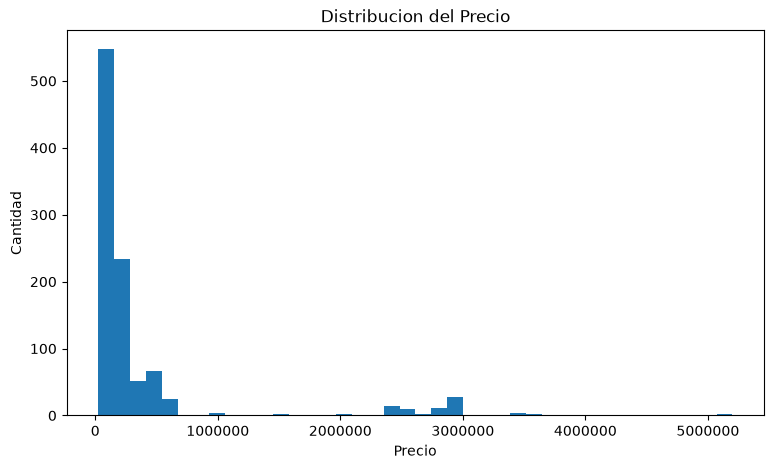

/tmp/ipykernel_15274/1011616321.py:41: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df['Price Numeric'], vert=False)


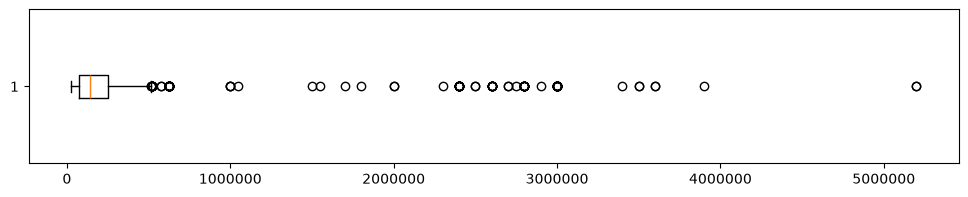

In [339]:
#Buscando posibles outliers que pudieron haber quedado luego de la limpieza.
print("Prices Below $25,000.00")
print(df[df['Price Numeric']<=25000][
    ['Car Make', 'Car Model', 
     'Year', 
     'Engine Type', 
     'Engine Size Numeric', 
     'Price Numeric'
     ]
].value_counts())

print("\nPrices from $1,000,000.00+")
print(df[df['Price Numeric']<=1000000][
    ['Car Make', 'Car Model', 
     'Year', 
     'Engine Type', 
     'Engine Size Numeric', 
     'Price Numeric'
     ]
].value_counts())

print("\nAsimetria en Precios:")
print(df['Price Numeric'].skew())

print("\nPercentiles de Price Numeric:")
print(df['Price Numeric'].describe(percentiles=[0.90, 0.95, 0.99]).apply(lambda x: f'{x:.2f}'))

#Histograma de distribucion de precios
plt.figure(figsize=(9,5))
plt.hist(df['Price Numeric'], bins=40)
plt.xlabel('Precio')
plt.ticklabel_format(style='plain', axis='x')
plt.ylabel('Cantidad')
plt.title('Distribucion del Precio')
plt.savefig('../graficas/01_histograma_precio.png')
plt.show()

#boxplot de precios buscando outliers

plt.figure(figsize=(12,2))
plt.boxplot(df['Price Numeric'], vert=False)
plt.ticklabel_format(style='plain', axis='x')
plt.savefig('../graficas/01_boxplot_precio')
plt.show()


### Resultado de Busqueda de valores atipicos

La varible objetivo (Price Numeric) presenta una distribucion altamente asimetrica (skewness = 3.25). El analisis mediante boxplot identifica multiples valores extremos; sin embarg, tras revisar los registros se comprobo que corresponden a vehiculos cuyos precios son consistentes con el mercado. Por ello, estos valores no se consideran errores de captura y se conservaran para el entrenamiento del modelo.

### Train/Test Split

In [234]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Size del split:")
print(f"   X_train: {X_train.shape}")
print(f"   X_test:  {X_test.shape}")
print(f"   y_train: {y_train.shape}")
print(f"   y_test: {y_test.shape}")
print()
print("Precios Promedio de Carros Deportivos en Train: ", round(y_train.mean(), 2))
print("Precios Promedio de Carros Deportivos en Test: ", round(y_test.mean(), 2))


Size del split:
   X_train: (805, 8)
   X_test:  (202, 8)
   y_train: (805,)
   y_test: (202,)

Precios Promedio de Carros Deportivos en Train:  375796.75
Precios Promedio de Carros Deportivos en Test:  406900.03


### One-Hot Encoding

In [235]:
columnas_categoricas = X.select_dtypes(include=['object', 'str']).columns
print("Columnas Categoricas: ",columnas_categoricas)
print()

X_train_enc = pd.get_dummies(X_train, columns=columnas_categoricas, drop_first=False)
X_test_enc = pd.get_dummies(X_test, columns=columnas_categoricas, drop_first=False)

#Alinear columnas
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

#Comparacion
print("Columnas ANTES del encoding: ", X_train.shape[1])
print("Columnas DESPUES del encoding: ", X_train_enc.shape[1])
print()

print("informacion de X_train:")
print(list(X_train.columns))
print()
print("Nueva info de las columnas:")
print(list(X_train_enc.columns))


Columnas Categoricas:  Index(['Car Make', 'Car Model', 'Engine Type'], dtype='str')

Columnas ANTES del encoding:  8
Columnas DESPUES del encoding:  203

informacion de X_train:
['Car Make', 'Car Model', 'Year', 'Engine Type', 'Engine Size Numeric', 'Horsepower Numeric', 'Torque Numeric', '0-60 MPH Time Numeric']

Nueva info de las columnas:
['Year', 'Engine Size Numeric', 'Horsepower Numeric', 'Torque Numeric', '0-60 MPH Time Numeric', 'Car Make_Acura', 'Car Make_Alfa Romeo', 'Car Make_Ariel', 'Car Make_Aston Martin', 'Car Make_Audi', 'Car Make_BMW', 'Car Make_Bentley', 'Car Make_Bugatti', 'Car Make_Chevrolet', 'Car Make_Dodge', 'Car Make_Ferrari', 'Car Make_Ford', 'Car Make_Jaguar', 'Car Make_Koenigsegg', 'Car Make_Lamborghini', 'Car Make_Lexus', 'Car Make_Lotus', 'Car Make_Maserati', 'Car Make_Mazda', 'Car Make_McLaren', 'Car Make_Mercedes-AMG', 'Car Make_Mercedes-Benz', 'Car Make_Nissan', 'Car Make_Pagani', 'Car Make_Pininfarina', 'Car Make_Porsche', 'Car Make_Rimac', 'Car Make_Rol

### EScalado de Variables Numericas

In [340]:
columnas_numericas = X.select_dtypes(include=['int', 'float']).columns
print(columnas_numericas)
print()

scaler = StandardScaler()

X_train_enc[columnas_numericas] = scaler.fit_transform(X_train_enc[columnas_numericas])
X_test_enc[columnas_numericas] = scaler.transform(X_test_enc[columnas_numericas])

print("Estadisticas de las variables numericas en X_train_enc:")
print(X_train_enc[columnas_numericas].describe().round(3))
print()
print("\nMedia de las variables numericas")
print(X_train_enc[columnas_numericas].mean().round(4))
print("\nDesviacion Standard de las variables numericas:")
print(X_train_enc[columnas_numericas].std().round(4))

Index(['Year', 'Engine Size Numeric', 'Horsepower Numeric', 'Torque Numeric',
       '0-60 MPH Time Numeric'],
      dtype='str')

Estadisticas de las variables numericas en X_train_enc:
          Year  Engine Size Numeric  Horsepower Numeric  Torque Numeric  \
count  805.000              805.000             805.000         805.000   
mean    -0.000                0.000              -0.000          -0.000   
std      1.001                1.001               1.001           1.001   
min    -25.560               -2.146              -1.497          -2.213   
25%     -0.087               -0.666              -0.580          -0.548   
50%     -0.087               -0.296              -0.120          -0.134   
75%      0.368                0.592               0.148           0.207   
max      0.823                2.960               4.522           4.891   

       0-60 MPH Time Numeric  
count                805.000  
mean                   0.000  
std                    1.001  
min          

In [237]:
#convertir Columnas booleanas a enteros

bool_columns = X_train_enc.select_dtypes(include='bool').columns

X_train_enc[bool_columns] = X_train_enc[bool_columns].astype('int64')
X_test_enc[bool_columns] = X_test_enc[bool_columns].astype('int64')

print("Dimensiones de los datos listos para el modelo:")
print("    X_train_enc:", X_train_enc.shape)
print("    X_test_enc:", X_test_enc.shape)
print("    y_train:", y_train.shape)
print("    y_test:", y_test.shape)
print()

print("\nEstadisticas Finales en Train de la Variable Target")
print(y_train.describe().apply(lambda x: f'{x:.2f}'))

print("\nEstadisticas Finales en Test de la Variable Target")
print(y_test.describe().apply(lambda x: f'{x:.2f}'))
print()

print("Valores nulos en X_train:", X_train_enc.isnull().sum().sum())
print("Valores nulos en X_test:", X_test_enc.isnull().sum().sum())
print()

print("Tipos de datos en X_train:")
print(X_train_enc.dtypes.value_counts())
print()

print("Columnas finales utilizadas por el modelo:")
print(list(X_train_enc.columns.tolist()))

Dimensiones de los datos listos para el modelo:
    X_train_enc: (805, 203)
    X_test_enc: (202, 203)
    y_train: (805,)
    y_test: (202,)


Estadisticas Finales en Train de la Variable Target
count        805.00
mean      375796.75
std       727642.46
min        25000.00
25%        71800.00
50%       134300.00
75%       242500.00
max      5200000.00
Name: Price Numeric, dtype: str

Estadisticas Finales en Test de la Variable Target
count        202.00
mean      406900.03
std       780821.90
min        35000.00
25%        72800.00
50%       149240.00
75%       276162.50
max      5200000.00
Name: Price Numeric, dtype: str

Valores nulos en X_train: 0
Valores nulos en X_test: 0

Tipos de datos en X_train:
int64      198
float64      5
Name: count, dtype: int64

Columnas finales utilizadas por el modelo:
['Year', 'Engine Size Numeric', 'Horsepower Numeric', 'Torque Numeric', '0-60 MPH Time Numeric', 'Car Make_Acura', 'Car Make_Alfa Romeo', 'Car Make_Ariel', 'Car Make_Aston Martin', 'Ca

### Modelo 1 de regresión: predecir el precio de los autos deportivos incluyendo Car Make y Car Model y las demas variables tecnicas.

vamos a predecir el precio de los autos deportivos del dataset en base a las caracteristicas que existen de cada vehiculo. 

In [238]:
modelo1_reg = LinearRegression()
modelo1_reg.fit(X_train_enc, y_train)

print("Coeficientes:")

for nombre, coef in zip(X_train_enc.columns, modelo1_reg.coef_):
    print(f" {nombre} : {round(coef, 2)}")

print()
print('Intercepto:', round(modelo1_reg.intercept_, 2))

Coeficientes:
 Year : 10819.33
 Engine Size Numeric : -4682.32
 Horsepower Numeric : 70142.78
 Torque Numeric : -1343.28
 0-60 MPH Time Numeric : 9868.14
 Car Make_Acura : -224223.56
 Car Make_Alfa Romeo : -371043.92
 Car Make_Ariel : -238799.27
 Car Make_Aston Martin : -298690.77
 Car Make_Audi : -478053.83
 Car Make_BMW : -469235.14
 Car Make_Bentley : -243837.29
 Car Make_Bugatti : 2357290.79
 Car Make_Chevrolet : -478068.75
 Car Make_Dodge : -506444.9
 Car Make_Ferrari : -285552.36
 Car Make_Ford : -12282.05
 Car Make_Jaguar : -342147.39
 Car Make_Koenigsegg : 1362290.53
 Car Make_Lamborghini : 238708.75
 Car Make_Lexus : -336837.93
 Car Make_Lotus : 71990.68
 Car Make_Maserati : -288254.23
 Car Make_Mazda : -269902.81
 Car Make_McLaren : -289405.3
 Car Make_Mercedes-AMG : -390078.05
 Car Make_Mercedes-Benz : -444788.74
 Car Make_Nissan : -428111.05
 Car Make_Pagani : 1657976.97
 Car Make_Pininfarina : 793612.37
 Car Make_Porsche : -361129.21
 Car Make_Rimac : 972942.95
 Car Make_R

In [239]:
#metricas

y_pred_modelo1 = modelo1_reg.predict(X_test_enc)

mae_reg_modelo1 = mean_absolute_error(y_test, y_pred_modelo1)
mse_reg_modelo1  = mean_squared_error(y_test, y_pred_modelo1)
rmse_reg_modelo1 = np.sqrt(mse_reg)
r2_reg_modelo1  = r2_score(y_test, y_pred_modelo1)

print("Metricas del modelo de Regresion Lineal Multiple")
print("MAE: ", round(mae_reg_modelo1,2))
print("MSE: ", round(mse_reg_modelo1, 2))
print("RMSE: ", round(rmse_reg_modelo1, 2))
print("R2: ", round(r2_reg_modelo1, 2))

Metricas del modelo de Regresion Lineal Multiple
MAE:  48899.11
MSE:  40218651670.47
RMSE:  200545.88
R2:  0.93


### Modelo 2 de regresión: predecir el precio de los autos deportivos excluyendo a 'Car Make' y 'Car Model'

vamos a predecir el precio de los autos deportivos del dataset en base a las caracteristicas tecnicas unicamente.

In [249]:
X_train_modelo2 = X_train_enc.copy()
X_test_modelo2 = X_test_enc.copy()

X_train_A = X_train_modelo2.drop(
    columns=[c for c in X_train_modelo2.columns
             if c.startswith('Car Make_') or c.startswith('Car Model_')]
)

X_test_A = X_test_modelo2.drop(
    columns=[c for c in X_test_modelo2.columns
             if c.startswith('Car Make_') or c.startswith('Car Model_')]
)

print('Dimensiones de X_train del Modelo 2 Sin (Car Make) y sin (Car Model)')
print('   X_train:', X_train_A.shape)
print('   X_test:', X_test_A.shape)
print('   y_train:', y_train.shape)
print('   y_test:', y_test.shape)

print("\nColumnas en X_train del Modelo 2 Sin (Car Make) y sin (Car Model)")
print(X_train_A.columns.tolist())

#Modelo Regersion Lineal
modelo_A = LinearRegression()
modelo_A.fit(X_train_A, y_train)

print("\nCoeficientes")
for nombre, coef in zip(X_train_A.columns, modelo_A.coef_):
    print(f" {nombre} : {round(coef, 2)}")

print("\nIntercepto:", round(modelo_A.intercept_,2))
print()

#Metricas

y_pred_modelo_A = modelo_A.predict(X_test_A)

mae_modelo_A = mean_absolute_error(y_test, y_pred_modelo_A)
mse_modelo_A = mean_squared_error(y_test, y_pred_modelo_A)
rmse_modelo_A = np.sqrt(mse_modelo_A)
r2_modelo_A = r2_score(y_test, y_pred_modelo_A)

print("\nMetricas del modelo de Regresion Lineal Multiple sin Variables 'Car Make' ni 'Car Model': ")
print("MAE: ", round(mae_modelo_A,2))
print("MSE: ", round(mse_modelo_A, 2))
print("RMSE: ", round(rmse_modelo_A, 2))
print("R2: ", round(r2_modelo_A, 2))

Dimensiones de X_train del Modelo 2 Sin (Car Make) y sin (Car Model)
   X_train: (805, 9)
   X_test: (202, 9)
   y_train: (805,)
   y_test: (202,)

Columnas en X_train del Modelo 2 Sin (Car Make) y sin (Car Model)
['Year', 'Engine Size Numeric', 'Horsepower Numeric', 'Torque Numeric', '0-60 MPH Time Numeric', 'Engine Type_Combustion', 'Engine Type_Electric', 'Engine Type_Hybrid', 'Engine Type_Unknown']

Coeficientes
 Year : -34913.03
 Engine Size Numeric : -30194.68
 Horsepower Numeric : 722930.0
 Torque Numeric : 58633.73
 0-60 MPH Time Numeric : 126246.65
 Engine Type_Combustion : 391926.88
 Engine Type_Electric : -487669.09
 Engine Type_Hybrid : 255074.48
 Engine Type_Unknown : -159332.28

Intercepto: 29534.21


Metricas del modelo de Regresion Lineal Multiple sin Variables 'Car Make' ni 'Car Model': 
MAE:  261841.34
MSE:  197590199767.01
RMSE:  444511.19
R2:  0.67


### Modelo 3 de regresión: predecir el precio de los autos deportivos excluyendo a 'Car Model'

vamos a predecir el precio de los autos deportivos del dataset en base a las caracteristicas tecnicas y la marca del modelo.

In [258]:
X_train_modelo3 = X_train_enc.copy()
X_test_modelo3 = X_test_enc.copy()

X_train_B = X_train_modelo3.drop(
    columns=[c for c in X_train_modelo3.columns if c.startswith('Car Model_')]
)

X_test_B = X_test_modelo3.drop(
    columns=[c for c in X_test_modelo3.columns if c.startswith('Car Model_')]
)

print('Dimensiones de X_train del Modelo 3 Sin (Car Model)')
print('   X_train:', X_train_B.shape)
print('   X_test:', X_test_B.shape)
print('   y_train:', y_train.shape)
print('   y_test:', y_test.shape)

#Modelo 3 
modelo_B = LinearRegression()
modelo_B.fit(X_train_B, y_train)

#Coeficientes e intercepto
print("\nCoeficientes:")
for nombre, coef in zip(X_train_B.columns, modelo_B.coef_):
    print(f" {nombre} : {round(coef, 2)}")

print("\nIntercepto:", modelo_B.intercept_)


#Metricas:
y_pred_modelo_B = modelo_B.predict(X_test_B)

mae_modelo_B = mean_absolute_error(y_test, y_pred_modelo_B)
mse_modelo_B = mean_squared_error(y_test, y_pred_modelo_B)
rmse_modelo_B = np.sqrt(mse_modelo_B)
r2_modelo_B = r2_score(y_test, y_pred_modelo_B)


print("\nMetricas del modelo de Regresion Lineal Multiple sin la variable 'Car Model': ")
print("MAE: ", round(mae_modelo_B,2))
print("MSE: ", round(mse_modelo_B, 2))
print("RMSE: ", round(rmse_modelo_B, 2))
print("R2: ", round(r2_modelo_B, 2))

Dimensiones de X_train del Modelo 3 Sin (Car Model)
   X_train: (805, 43)
   X_test: (202, 43)
   y_train: (805,)
   y_test: (202,)

Coeficientes:
 Year : -59301.86
 Engine Size Numeric : -64172.09
 Horsepower Numeric : 477052.82
 Torque Numeric : -135754.3
 0-60 MPH Time Numeric : 21936.66
 Car Make_Acura : -330248.94
 Car Make_Alfa Romeo : -304168.31
 Car Make_Ariel : -220942.85
 Car Make_Aston Martin : -233201.55
 Car Make_Audi : -301484.39
 Car Make_BMW : -294690.2
 Car Make_Bentley : -171332.36
 Car Make_Bugatti : 1832602.54
 Car Make_Chevrolet : -262505.51
 Car Make_Dodge : -446476.2
 Car Make_Ferrari : -357948.67
 Car Make_Ford : -165140.66
 Car Make_Jaguar : -271374.8
 Car Make_Koenigsegg : 1586477.1
 Car Make_Lamborghini : -143990.85
 Car Make_Lexus : -245081.59
 Car Make_Lotus : -235984.03
 Car Make_Maserati : -217295.75
 Car Make_Mazda : -200489.67
 Car Make_McLaren : -284168.19
 Car Make_Mercedes-AMG : -295508.72
 Car Make_Mercedes-Benz : -306695.28
 Car Make_Nissan : -2611

### Modelo 4 de regresión: predecir el precio de los autos deportivos excluyendo a 'Car Make'

vamos a predecir el precio de los autos deportivos del dataset en base a las caracteristicas tecnicas y el modelo del vehiculo.

In [267]:
X_train_modelo4 = X_train_enc.copy()
X_test_modelo4 = X_test_enc.copy()

X_train_C = X_train_modelo4.drop(columns=[c for c in X_train_modelo4.columns if c.startswith('Car Make_')])
X_test_C = X_test_modelo4.drop(columns=[c for c in X_test_modelo4.columns if c.startswith('Car Make_')])

print('\nDimensiones de X_train del Modelo 4 Sin (Car Make)')
print('   X_train:', X_train_C.shape)
print('   X_test:', X_test_C.shape)
print('   y_train:', y_train.shape)
print('   y_test:', y_test.shape)

#Regresion Lineal sin Car Make
modelo_C = LinearRegression()
modelo_C.fit(X_train_C, y_train)

#Coeficientes
print("\nCoeficientes")
for nombre, coef in zip(X_train_C.columns, modelo_C.coef_):
    print(f"    {nombre} : {round(coef, 2)}")

#Intercepto
print("\nIntercepto:")
print(f"    {modelo_C.intercept_:.4f} ")

#Metricas:
y_pred_modelo_C = modelo_C.predict(X_test_C)

mae_modelo_C = mean_absolute_error(y_test, y_pred_modelo_C)
mse_modelo_C = mean_squared_error(y_test, y_pred_modelo_C)
rmse_modelo_C = np.sqrt(mse_modelo_C)
r2_modelo_C = r2_score(y_test, y_pred_modelo_C)

print("\nMetricas del modelo de Regresion Lineal Multiple sin la variable 'Car Make': ")
print("MAE: ", round(mae_modelo_C,2))
print("MSE: ", round(mse_modelo_C, 2))
print("RMSE: ", round(rmse_modelo_C, 2))
print("R2: ", round(r2_modelo_C, 2))




Dimensiones de X_train del Modelo 4 Sin (Car Make)
   X_train: (805, 169)
   X_test: (202, 169)
   y_train: (805,)
   y_test: (202,)

Coeficientes
    Year : 13948.2
    Engine Size Numeric : -53599.82
    Horsepower Numeric : 98620.64
    Torque Numeric : 38786.87
    0-60 MPH Time Numeric : -13066.48
    Car Model_370Z : -233458.95
    Car Model_370Z Coupe : -227671.87
    Car Model_370Z Nismo : -225808.06
    Car Model_400Z : -316371.18
    Car Model_488 GTB : -117171.2
    Car Model_4C : -251456.07
    Car Model_4C Spider : -250839.4
    Car Model_570S : -199706.56
    Car Model_570S Spider : -180174.42
    Car Model_600LT : -161721.27
    Car Model_600LT Spider : -155952.5
    Car Model_718 Boxster : -265345.33
    Car Model_718 Cayman : -270014.2
    Car Model_718 Cayman GT4 : -202895.41
    Car Model_720S : -164924.2
    Car Model_765LT : -121674.49
    Car Model_812 Superfast : -29552.24
    Car Model_911 : -238847.39
    Car Model_911 Turbo S : -251169.06
    Car Model_918 Sp

### Comparacion de los Modelos e interpretacion de la regresion Lineal

In [282]:
#Comparacion de metricas de los diferentes modelos

comparacion_modelos = pd.DataFrame({
    'Modelo 1': [
        mae_reg_modelo1,
        mse_reg_modelo1,
        rmse_reg_modelo1,
        r2_reg_modelo1
    ],
    'Modelo 2' : [
        mae_modelo_A,
        mse_modelo_A,
        rmse_modelo_A,
        r2_modelo_A
    ],
    'Modelo 3': [
        mae_modelo_B,
        mse_modelo_B,
        rmse_modelo_B,
        r2_modelo_B
    ],
    'Modelo 4': [
        mae_modelo_C,
        mse_modelo_C,
        rmse_modelo_C,
        r2_modelo_C
    ]
    
}, index=[
    'MAE',
    'MSE',
    'RMSE',
    'R2'

])


print("Modelo 1 - Contiene las variables tecnicas y a 'Car Make' y 'Car Model'")
print("Modelo 2 - Sin 'Car Make' y sin 'Car Model' ")
print("Modelo 3 - Sin 'Car Model)")
print("Modelo 4 - Sin 'Car Make'")
print("\nComparativa de los 4 Modelos de Regresion Lineal Multiples implementados")
print(comparacion_modelos.map(lambda x: f'{x:,.2f}' if abs(x) >= 1 else f'{x:.4f}').to_string())

Modelo 1 - Contiene las variables tecnicas y a 'Car Make' y 'Car Model'
Modelo 2 - Sin 'Car Make' y sin 'Car Model' 
Modelo 3 - Sin 'Car Model)
Modelo 4 - Sin 'Car Make'

Comparativa de los 4 Modelos de Regresion Lineal Multiples implementados
               Modelo 1            Modelo 2           Modelo 3           Modelo 4
MAE           48,899.11          261,841.34          98,971.19          81,245.67
MSE   40,218,651,670.47  197,590,199,767.01  56,495,976,674.92  85,531,005,554.39
RMSE         200,545.88          444,511.19         237,688.82         292,456.84
R2               0.9337              0.6743             0.9069             0.8590


### Interpretando los 4 modelos de regresion lineal

Se entrenaron cuatro modelos de regresión lineal utilizando diferentes conjuntos de variables con el objetivo de evaluar el aporte de la marca y el modelo del vehículo en la predicción del precio.

El Modelo 2, que únicamente utilizó variables técnicas, obtuvo un R² de 0.6743, demostrando que las especificaciones mecánicas explican aproximadamente el 67% de la variabilidad del precio.

Al incorporar la marca del vehículo (Modelo 3), el coeficiente de determinación aumentó hasta 0.9069, evidenciando que la marca constituye uno de los factores más relevantes para explicar el valor de mercado de un automóvil deportivo.

Cuando únicamente se añadió el modelo del vehículo (Modelo 4), el desempeño también mejoró considerablemente alcanzando un R² de 0.8590, aunque inferior al obtenido al incluir la marca.

Finalmente, el Modelo 1, que incorporó tanto la marca como el modelo junto con las variables técnicas, obtuvo el mejor desempeño con un R² de 0.9337 y los menores errores (MAE y RMSE), convirtiéndose en el modelo seleccionado para este proyecto.

### Probando los modelos con un nuevo vehiculo deportivo:

| Car Make  | Car Model    | Year | Engine Type | Engine Size Numeric | Horsepower Numeric | Torque Numeric | 0-60 MPH Time Numeric |
| --------- | ------------ | ---- | ----------- | ------------------: | -----------------: | -------------: | --------------------: |
| Chevrolet | Corvette ZR1 | 2025 | Combustion  |                 5.5 |               1064 |            828 |                   2.3 |


In [327]:
#nuevo Vehiculo 

nuevo_vehiculo = pd.DataFrame({
    'Car Make': ['Ferrari'],
    'Car Model': ['F80'],
    'Year': [2026],
    'Engine Type': ['Hybrid'],
    'Engine Size Numeric': [3.0],
    'Horsepower Numeric': [1184],
    'Torque Numeric': [850],
    '0-60 MPH Time Numeric': [2.1]
})


In [328]:
#Prueba de Nuevo vehiculo con Modelo 1

nuevo_reg_modelo1 = nuevo_vehiculo.copy()
print(nuevo_reg_modelo1.to_string())
print()

variables_categoricas_modelo1 = nuevo_reg_modelo1.select_dtypes(include=['object', 'str']).columns
print("Variables Categoricas: ", variables_categoricas_modelo1)
print()

#one-hot encoding
nuevo_enc_modelo1 = pd.get_dummies(nuevo_reg_modelo1, columns=variables_categoricas_modelo1, drop_first=False)

#alinear columnas con X_train del modelo 1
nuevo_enc_modelo1 = nuevo_enc_modelo1.reindex(columns=X_train_enc.columns, fill_value=0)

#comprobar que el cliente nuevo esta alineado y listo para usarlo con el modelo
print("Dimensiones del cliente nuevo: ", nuevo_enc_modelo1.shape)
print("Dimensiones de X_train:", X_train_enc.shape)

#convertir columnas  booleanas a enteros
nuevo_bool_modelo1 = nuevo_enc_modelo1.select_dtypes(include='bool').columns
nuevo_enc_modelo1[nuevo_bool_modelo1] = nuevo_enc_modelo1[nuevo_bool_modelo1].astype('int')

#Standard Scaler
variables_numericas_model1 = nuevo_reg_modelo1.select_dtypes(include=['int', 'float']).columns
nuevo_enc_modelo1[variables_numericas_model1] = scaler.transform(nuevo_enc_modelo1[variables_numericas_model1])

#validacion final de nuevo cliente antes de pasarlo al modelo:
print("\nTipos de datos del nuevo client")
print(nuevo_enc_modelo1.dtypes.value_counts())
print()
print("Tiene las mismas columnas que X_train?:")
print(nuevo_enc_modelo1.columns.equals(X_train_enc.columns))

#Usar el nuevo vehiculo en modelo 1

nuevo_predicho_modelo1 = modelo1_reg.predict(nuevo_enc_modelo1)
print(f"\nPrediccion del Precio del Nuevo Vehiculo usando el Modelo 1: ${nuevo_predicho_modelo1[0]:.2f}")




  Car Make Car Model  Year Engine Type  Engine Size Numeric  Horsepower Numeric  Torque Numeric  0-60 MPH Time Numeric
0  Ferrari       F80  2026      Hybrid                  3.0                1184             850                    2.1

Variables Categoricas:  Index(['Car Make', 'Car Model', 'Engine Type'], dtype='str')

Dimensiones del cliente nuevo:  (1, 203)
Dimensiones de X_train: (805, 203)

Tipos de datos del nuevo client
int64      198
float64      5
Name: count, dtype: int64

Tiene las mismas columnas que X_train?:
True

Prediccion del Precio del Nuevo Vehiculo usando el Modelo 1: $484582.71


In [ ]:
#Prueba de Nuevo vehiculo con Modelo 2 excluyendo 'Car Make' y 'Car Model'.

nuevo_reg_modelo2 = nuevo_vehiculo.copy()
print(nuevo_reg_modelo2.to_string())
print()

variables_categoricas_modelo2 = ['Engine Type']
print("Variables Categoricas: ", variables_categoricas_modelo2)
print()

#one-hot encoding
nuevo_enc_modelo2 = pd.get_dummies(nuevo_reg_modelo2, columns=variables_categoricas_modelo2, drop_first=False)

#alinear columnas con X_train del modelo 1
nuevo_enc_modelo2 = nuevo_enc_modelo2.reindex(columns=X_train_A.columns, fill_value=0)

#comprobar que el cliente nuevo esta alineado y listo para usarlo con el modelo
print("Dimensiones del cliente nuevo: ", nuevo_enc_modelo2.shape)
print("Dimensiones de X_train:", X_train_A.shape)

#convertir columnas  booleanas a enteros
nuevo_bool_modelo2 = nuevo_enc_modelo2.select_dtypes(include='bool').columns
nuevo_enc_modelo2[nuevo_bool_modelo2] = nuevo_enc_modelo2[nuevo_bool_modelo2].astype('int')

#Standard Scaler
variables_numericas_model2 = nuevo_reg_modelo2.select_dtypes(include=['int', 'float']).columns
nuevo_enc_modelo2[variables_numericas_model2] = scaler.transform(nuevo_enc_modelo2[variables_numericas_model2])

#validacion final de nuevo cliente antes de pasarlo al modelo:
print("\nTipos de datos del nuevo client")
print(nuevo_enc_modelo2.dtypes.value_counts())
print()
print("Tiene las mismas columnas que X_train?:")
print(nuevo_enc_modelo2.columns.equals(X_train_A.columns))

#Usar el nuevo vehiculo en modelo 1

nuevo_predicho_modelo2 = modelo_A.predict(nuevo_enc_modelo2)
print(f"\nPrediccion del Precio del Nuevo Vehiculo usando el Modelo 1: ${nuevo_predicho_modelo2[0]:.2f}")




  Car Make Car Model  Year Engine Type  Engine Size Numeric  Horsepower Numeric  Torque Numeric  0-60 MPH Time Numeric
0  Ferrari       F80  2026      Hybrid                  3.0                1184             850                    2.1

Variables Categoricas:  ['Engine Type']

Dimensiones del cliente nuevo:  (1, 9)
Dimensiones de X_train: (805, 9)

Tipos de datos del nuevo client
float64    5
int64      4
Name: count, dtype: int64

Tiene las mismas columnas que X_train?:
True

Prediccion del Precio del Nuevo Vehiculo usando el Modelo 1: $1439957.53


In [334]:
#Prueba de Nuevo vehiculo con Modelo 3 excluyendo a 'Car Model'.

nuevo_reg_modelo3 = nuevo_vehiculo.copy()
print(nuevo_reg_modelo3.to_string())
print()

variables_categoricas_modelo3 = ['Car Make', 'Engine Type']
print("Variables Categoricas: ", variables_categoricas_modelo3)
print()

#one-hot encoding
nuevo_enc_modelo3 = pd.get_dummies(nuevo_reg_modelo3, columns=variables_categoricas_modelo3, drop_first=False)

#alinear columnas con X_train del modelo 1
nuevo_enc_modelo3 = nuevo_enc_modelo3.reindex(columns=X_train_B.columns, fill_value=0)

#comprobar que el cliente nuevo esta alineado y listo para usarlo con el modelo
print("Dimensiones del cliente nuevo: ", nuevo_enc_modelo3.shape)
print("Dimensiones de X_train:", X_train_B.shape)

#convertir columnas  booleanas a enteros
nuevo_bool_modelo3 = nuevo_enc_modelo3.select_dtypes(include='bool').columns
nuevo_enc_modelo3[nuevo_bool_modelo3] = nuevo_enc_modelo3[nuevo_bool_modelo3].astype('int')

#Standard Scaler
variables_numericas_model3 = nuevo_reg_modelo3.select_dtypes(include=['int', 'float']).columns
nuevo_enc_modelo3[variables_numericas_model3] = scaler.transform(nuevo_enc_modelo3[variables_numericas_model3])

#validacion final de nuevo cliente antes de pasarlo al modelo:
print("\nTipos de datos del nuevo client")
print(nuevo_enc_modelo3.dtypes.value_counts())
print()
print("Tiene las mismas columnas que X_train?:")
print(nuevo_enc_modelo3.columns.equals(X_train_B.columns))

#Usar el nuevo vehiculo en modelo 1

nuevo_predicho_modelo3 = modelo_B.predict(nuevo_enc_modelo3)
print(f"\nPrediccion del Precio del Nuevo Vehiculo usando el Modelo 1: ${nuevo_predicho_modelo3[0]:.2f}")




  Car Make Car Model  Year Engine Type  Engine Size Numeric  Horsepower Numeric  Torque Numeric  0-60 MPH Time Numeric
0  Ferrari       F80  2026      Hybrid                  3.0                1184             850                    2.1

Variables Categoricas:  ['Car Make', 'Engine Type']

Dimensiones del cliente nuevo:  (1, 43)
Dimensiones de X_train: (805, 43)

Tipos de datos del nuevo client
int64      38
float64     5
Name: count, dtype: int64

Tiene las mismas columnas que X_train?:
True

Prediccion del Precio del Nuevo Vehiculo usando el Modelo 1: $745774.02


In [335]:
#Prueba de Nuevo vehiculo con Modelo 4 excluyendo a 'Car Make'.

nuevo_reg_modelo4 = nuevo_vehiculo.copy()
print(nuevo_reg_modelo4.to_string())
print()

variables_categoricas_modelo4 = ['Car Model', 'Engine Type']
print("Variables Categoricas: ", variables_categoricas_modelo4)
print()

#one-hot encoding
nuevo_enc_modelo4 = pd.get_dummies(nuevo_reg_modelo4, columns=variables_categoricas_modelo4, drop_first=False)

#alinear columnas con X_train del modelo 1
nuevo_enc_modelo4 = nuevo_enc_modelo4.reindex(columns=X_train_C.columns, fill_value=0)

#comprobar que el cliente nuevo esta alineado y listo para usarlo con el modelo
print("Dimensiones del cliente nuevo: ", nuevo_enc_modelo4.shape)
print("Dimensiones de X_train:", X_train_C.shape)

#convertir columnas  booleanas a enteros
nuevo_bool_modelo4 = nuevo_enc_modelo4.select_dtypes(include='bool').columns
nuevo_enc_modelo4[nuevo_bool_modelo4] = nuevo_enc_modelo4[nuevo_bool_modelo4].astype('int')

#Standard Scaler
variables_numericas_model4 = nuevo_reg_modelo4.select_dtypes(include=['int', 'float']).columns
nuevo_enc_modelo4[variables_numericas_model4] = scaler.transform(nuevo_enc_modelo4[variables_numericas_model4])

#validacion final de nuevo cliente antes de pasarlo al modelo:
print("\nTipos de datos del nuevo client")
print(nuevo_enc_modelo4.dtypes.value_counts())
print()
print("Tiene las mismas columnas que X_train?:")
print(nuevo_enc_modelo4.columns.equals(X_train_C.columns))

#Usar el nuevo vehiculo en modelo 1

nuevo_predicho_modelo4 = modelo_C.predict(nuevo_enc_modelo4)
print(f"\nPrediccion del Precio del Nuevo Vehiculo usando el Modelo 1: ${nuevo_predicho_modelo4[0]:.2f}")




  Car Make Car Model  Year Engine Type  Engine Size Numeric  Horsepower Numeric  Torque Numeric  0-60 MPH Time Numeric
0  Ferrari       F80  2026      Hybrid                  3.0                1184             850                    2.1

Variables Categoricas:  ['Car Model', 'Engine Type']

Dimensiones del cliente nuevo:  (1, 169)
Dimensiones de X_train: (805, 169)

Tipos de datos del nuevo client
int64      164
float64      5
Name: count, dtype: int64

Tiene las mismas columnas que X_train?:
True

Prediccion del Precio del Nuevo Vehiculo usando el Modelo 1: $756885.70


In [338]:
#Comparativa de Uso de una nuevo Vehiculo usando los 4 modelos

Comparando_datos_nuevos = pd.DataFrame({
    'Modelo 1': nuevo_predicho_modelo1, 
    'Modelo 2': nuevo_predicho_modelo2,
    'Modelo 3': nuevo_predicho_modelo3,
    'Modelo 4': nuevo_predicho_modelo4
    
}, index=['Prediccion']
    
)

print("Modelo 1 - Contiene las variables tecnicas y a 'Car Make' y 'Car Model'")
print("Modelo 2 - Sin 'Car Make' y sin 'Car Model' ")
print("Modelo 3 - Sin 'Car Model)")
print("Modelo 4 - Sin 'Car Make'")
print("\nComparativa de los 4 Modelos de Regresion Lineal Multiples implementados")
print(Comparando_datos_nuevos.map(lambda x: f'{x:,.2f}' if abs(x) >= 1 else f'{x:.4f}').to_string())

Modelo 1 - Contiene las variables tecnicas y a 'Car Make' y 'Car Model'
Modelo 2 - Sin 'Car Make' y sin 'Car Model' 
Modelo 3 - Sin 'Car Model)
Modelo 4 - Sin 'Car Make'

Comparativa de los 4 Modelos de Regresion Lineal Multiples implementados
              Modelo 1      Modelo 2    Modelo 3    Modelo 4
Prediccion  484,582.71  1,439,957.53  745,774.02  756,885.70


### Conclusion de este Notebook

El Modelo 1 obtuvo el mejor desempeño estadístico (R² = 0.9337), siendo el más preciso sobre el conjunto de prueba. Sin embargo, al evaluar un vehículo completamente nuevo (Ferrari F80 2026), el modelo produjo una estimación considerablemente inferior al precio esperado, debido a que el modelo nunca observó dicho vehículo durante el entrenamiento. En contraste, el Modelo 2, basado únicamente en variables técnicas, produjo una estimación mucho mayor, evidenciando una mejor capacidad para extrapolar a vehículos inéditos, aunque con menor precisión general. Este experimento demuestra el compromiso existente entre precisión sobre datos conocidos y capacidad de generalización.